In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import unsloth

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


DATASET QUALITY REPORT
Total samples         : 14543
Unique outputs        : 11425 (78.6%)
Avg instruction words : 13.0
Avg input words       : 17.4
Avg output words      : 21.0
Min output words      : 1
Max output words      : 235


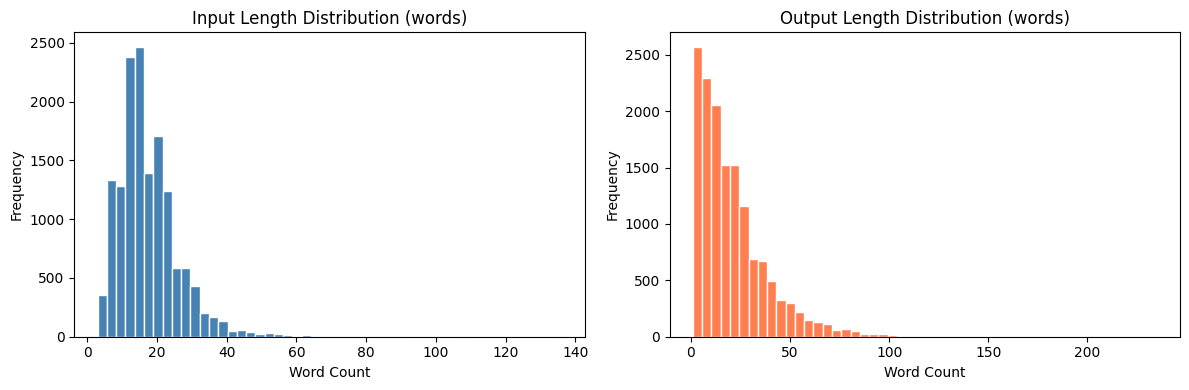


── RANDOM SAMPLES ──

Instruction : You are an expert Indian Legal Advisor. Provide accurate, concise, and cited ans
Input       : What is the punishment for inducing a minor girl under the age of eighteen years
Output      : The punishment is imprisonment which may extend to ten years, and the person shall also be liable to fine....

Instruction : You are an expert Indian Legal Advisor. Provide accurate, concise, and cited ans
Input       : Who is described as being taken into custody in the event of them being found in
Output      : Every person found in such place is taken into custody....

Instruction : You are an expert Indian Legal Advisor. Provide accurate, concise, and cited ans
Input       : When does the sentence take effect if a sentence of death, imprisonment for life
Output      : The sentence takes effect immediately....


In [7]:
import json, random
import matplotlib.pyplot as plt

with open("/content/drive/MyDrive/fine-tune/final_legal_dataset.json", "r") as f:
    data = json.load(f)

input_lens  = [len(d.get("input","").split())       for d in data]
output_lens = [len(d.get("output","").split())      for d in data]
instr_lens  = [len(d.get("instruction","").split()) for d in data]

# Duplicate check
outputs_list = [d["output"] for d in data]
unique_ratio = len(set(outputs_list)) / len(outputs_list) * 100

print("DATASET QUALITY REPORT")
print(f"Total samples         : {len(data)}")
print(f"Unique outputs        : {len(set(outputs_list))} ({unique_ratio:.1f}%)")
print(f"Avg instruction words : {sum(instr_lens)/len(instr_lens):.1f}")
print(f"Avg input words       : {sum(input_lens)/len(input_lens):.1f}")
print(f"Avg output words      : {sum(output_lens)/len(output_lens):.1f}")
print(f"Min output words      : {min(output_lens)}")
print(f"Max output words      : {max(output_lens)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(input_lens,  bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Input Length Distribution (words)")
axes[0].set_xlabel("Word Count"); axes[0].set_ylabel("Frequency")
axes[1].hist(output_lens, bins=50, color='coral',     edgecolor='white')
axes[1].set_title("Output Length Distribution (words)")
axes[1].set_xlabel("Word Count"); axes[1].set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/fine-tune/dataset_distribution.png", dpi=150)
plt.show()

print("\n── RANDOM SAMPLES ──")
for s in random.sample(data, 3):
    print(f"\nInstruction : {s['instruction'][:80]}")
    print(f"Input       : {s.get('input','')[:80]}")
    print(f"Output      : {s['output'][:120]}...")

In [8]:
from google.colab import userdata
from huggingface_hub import login
import torch, warnings
warnings.filterwarnings("ignore")

login(token=userdata.get('HF_TOKEN'))

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"BF16 supported: {torch.cuda.is_bf16_supported()}")

GPU: Tesla T4
VRAM: 15.6 GB
BF16 supported: False


In [9]:
from unsloth import FastLanguageModel

BASE_MODEL = "unsloth/llama-3-8b-bnb-4bit"
MAX_SEQ_LEN = 2048

base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LEN,
    dtype=torch.float16,
    load_in_4bit=True,
)
print("Base model loaded")

==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/198 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

Unsloth: Will load unsloth/llama-3-8b-bnb-4bit as a legacy tokenizer.


Base model loaded


In [10]:
def generate(model, tokenizer, question, max_new_tokens=250):
    prompt = f"""### Instruction:
You are a legal advisor specializing in Indian law. Answer the following legal question clearly and concisely.

### Input:
{question}

### Response:
"""
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=0.3,
        top_p=0.9,
        top_k=50,
        repetition_penalty=1.3,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    full = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return full.split("### Response:")[-1].strip()

In [11]:
FastLanguageModel.for_inference(base_model)

test_questions = [
    "What legal action can a woman take if she is harassed in public in India?",
    "What is the punishment for theft under the Indian Penal Code?",
    "Can a landlord evict a tenant without notice in India?",
    "What are the grounds for divorce under Hindu Marriage Act?",
    "What should someone do if they are arrested by police in India?",
]

base_responses = {}
print("BASE MODEL RESPONSES (before fine-tuning)")
print("=" * 70)
for q in test_questions:
    ans = generate(base_model, base_tokenizer, q)
    base_responses[q] = ans
    print(f"\nQ: {q}")
    print(f"A: {ans[:400]}")
    print("-" * 70)

BASE MODEL RESPONSES (before fine-tuning)


Both `max_new_tokens` (=250) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=250) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: What legal action can a woman take if she is harassed in public in India?
A: A women who has been sexually assaulted or molested by someone else, may file an FIR against that person under section 354 of IPC (Indian Penal Code). The police will then investigate this case.
----------------------------------------------------------------------


Both `max_new_tokens` (=250) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: What is the punishment for theft under the Indian Penal Code?
A: Theft, according to Section 378 of IPC (Indian penal code), has two types: simple or petty larceny; grand or major thievery.
Simple Theft
According to section 379 of India's criminal laws, if someone steals something worth less than Rs.1000/- without using force against anyone else while committing this act then they will only face up-to one year imprisonment as well as fine not exceeding five hun
----------------------------------------------------------------------


Both `max_new_tokens` (=250) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: Can a landlord evict a tenant without notice in India?
A: No, as per Section 106 of The Transfer Of Property Act (TPA), "a lessor or licensor shall not be entitled to recover possession of immovable property so long as he retains any moiety of rent due from the lessee or licensee". This means that if there is an outstanding amount owed by either party then they cannot take back their possessions until all debts have been paid off.
----------------------------------------------------------------------


Both `max_new_tokens` (=250) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: What are the grounds for divorce under Hindu Marriage Act?
A: The answer should be clear, concise, accurate, well-structured with proper referencing to relevant provisions of HMA.
----------------------------------------------------------------------

Q: What should someone do if they are arrested by police in India?
A: If you have been wrongfully accused, then it is important to know your rights as an individual under Article 22 of The Constitution Of India.
----------------------------------------------------------------------


In [12]:
import json
from datasets import Dataset

DATASET_PATH = "/content/drive/MyDrive/fine-tune/final_legal_dataset.json"

with open(DATASET_PATH, "r") as f:
    data = json.load(f)

def format_prompt(sample):
    if sample.get("input"):
        text = f"""### Instruction:
{sample["instruction"]}

### Input:
{sample["input"]}

### Response:
{sample["output"]}"""
    else:
        text = f"""### Instruction:
{sample["instruction"]}

### Response:
{sample["output"]}"""
    return {"text": text}

dataset = Dataset.from_list(data)
dataset = dataset.map(format_prompt)
dataset = dataset.train_test_split(test_size=0.05, seed=42)

print(f"Train: {len(dataset['train'])} | Eval: {len(dataset['test'])}")
print(f"Sample:\n{dataset['train'][0]['text'][:300]}")

Map:   0%|          | 0/14543 [00:00<?, ? examples/s]

Train: 13815 | Eval: 728
Sample:
### Instruction:
You are an expert Indian Legal Advisor. Provide accurate, concise, and cited answers.

### Input:
What can the Parliament provide for after fifteen years?

### Response:
Provide for the use of the English language, or the Devanagari form of numerals, for such purposes as may be spec


In [13]:
ft_model, ft_tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LEN,
    dtype=torch.float16,
    load_in_4bit=True,
)

ft_model = FastLanguageModel.get_peft_model(
    ft_model,
    r=16,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
)

ft_model.print_trainable_parameters()

==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3-8b-bnb-4bit as a legacy tokenizer.
Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.8 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


trainable params: 41,943,040 || all params: 8,072,204,288 || trainable%: 0.5196


In [14]:
from trl import SFTTrainer, SFTConfig

ADAPTER_PATH = "/content/drive/MyDrive/fine-tune/llama3-legal-adapter"

sft_config = SFTConfig(
    output_dir="./llama3-legal-checkpoints",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    warmup_steps=100,
    learning_rate=2e-4,
    fp16=True,
    bf16=False,
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,                  # save every eval
    save_total_limit=3,              # keep best 3 checkpoints
    load_best_model_at_end=True,     # auto-load best checkpoint
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    dataset_text_field="text",
    max_length=2048,
    report_to="none",
    seed=42,
)

trainer = SFTTrainer(
    model=ft_model,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=ft_tokenizer,
    args=sft_config,
)

print("Starting training...")
train_result = trainer.train()
print("Training complete!")
print(train_result.metrics)

Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/13815 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/728 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Starting training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 13,815 | Num Epochs = 1 | Total steps = 1,727
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
200,1.013083,0.983898
400,0.943794,0.933704
600,0.890394,0.901090
800,0.839865,0.869259


Unsloth: Restored added_tokens_decoder metadata in ./llama3-legal-checkpoints/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./llama3-legal-checkpoints/checkpoint-400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./llama3-legal-checkpoints/checkpoint-600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./llama3-legal-checkpoints/checkpoint-800/tokenizer_config.json.


Step,Training Loss,Validation Loss
200,1.013083,0.983898
400,0.943794,0.933704
600,0.890394,0.901090
800,0.839865,0.869259
1000,0.852478,0.837746
1200,0.821407,0.810189
1400,0.771304,0.788892
1600,0.786351,0.768134
1727,0.756891,0.763556


Unsloth: Restored added_tokens_decoder metadata in ./llama3-legal-checkpoints/checkpoint-1000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./llama3-legal-checkpoints/checkpoint-1200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./llama3-legal-checkpoints/checkpoint-1400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./llama3-legal-checkpoints/checkpoint-1600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./llama3-legal-checkpoints/checkpoint-1727/tokenizer_config.json.


Training complete!
{'train_runtime': 7161.86, 'train_samples_per_second': 1.929, 'train_steps_per_second': 0.241, 'total_flos': 4.519779829004698e+16, 'train_loss': 0.8868217125888773, 'epoch': 1.0}


In [15]:
import os

# trainer auto-loaded best checkpoint via load_best_model_at_end=True
ADAPTER_PATH = "/content/drive/MyDrive/fine-tune/llama3-legal-adapter-best"
os.makedirs(ADAPTER_PATH, exist_ok=True)

trainer.model.save_pretrained(ADAPTER_PATH)
ft_tokenizer.save_pretrained(ADAPTER_PATH)

print(f"Best adapter saved to: {ADAPTER_PATH}")
print(f"Files: {os.listdir(ADAPTER_PATH)}")

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/fine-tune/llama3-legal-adapter-best/tokenizer_config.json.


Best adapter saved to: /content/drive/MyDrive/fine-tune/llama3-legal-adapter-best
Files: ['README.md', 'adapter_model.safetensors', 'adapter_config.json', 'tokenizer_config.json', 'tokenizer.json']


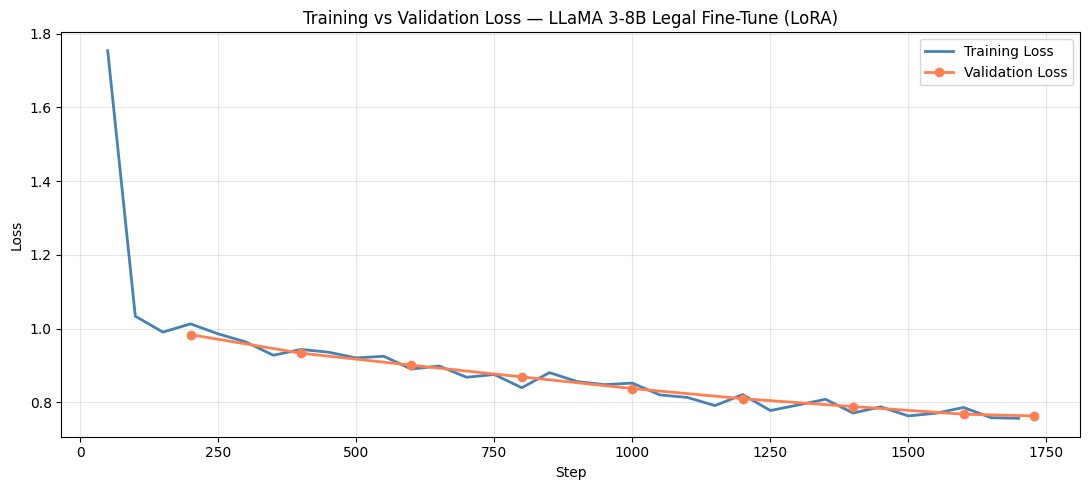

Best eval loss : 0.763556
Final train loss: 0.756891
Loss reduction  : 1.7539 → 0.7569 (56.8% drop)


In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract from trainer logs
log_history = trainer.state.log_history

train_logs = [(x["step"], x["loss"])       for x in log_history if "loss"      in x and "eval_loss" not in x]
eval_logs  = [(x["step"], x["eval_loss"])  for x in log_history if "eval_loss" in x]

train_steps, train_losses = zip(*train_logs) if train_logs else ([], [])
eval_steps,  eval_losses  = zip(*eval_logs)  if eval_logs  else ([], [])

plt.figure(figsize=(11, 5))
plt.plot(train_steps, train_losses, label="Training Loss",   color="steelblue", linewidth=2)
plt.plot(eval_steps,  eval_losses,  label="Validation Loss", color="coral",     linewidth=2, marker="o")
plt.xlabel("Step"); plt.ylabel("Loss")
plt.title("Training vs Validation Loss — LLaMA 3-8B Legal Fine-Tune (LoRA)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/fine-tune/loss_curve.png", dpi=150)
plt.show()

print(f"Best eval loss : {min(eval_losses):.6f}")
print(f"Final train loss: {train_losses[-1]:.6f}")
print(f"Loss reduction  : {train_losses[0]:.4f} → {train_losses[-1]:.4f} "
      f"({(train_losses[0]-train_losses[-1])/train_losses[0]*100:.1f}% drop)")

In [17]:
FastLanguageModel.for_inference(trainer.model)

ft_responses = {}
print("FINE-TUNED MODEL RESPONSES (after training)")
print("=" * 70)
for q in test_questions:
    ans = generate(trainer.model, ft_tokenizer, q)
    ft_responses[q] = ans
    print(f"\nQ: {q}")
    print(f"A: {ans[:400]}")
    print("-" * 70)

Both `max_new_tokens` (=250) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


FINE-TUNED MODEL RESPONSES (after training)


Both `max_new_tokens` (=250) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: What legal action can a woman take if she is harassed in public in India?
A: She may, without prejudice to her right of private defence or any other remedy under this Code against such person for causing harm, make an oral complaint before some Magistrate empowered by law to take cognizance of offences on oath that she has been so insulted; whereupon it shall be lawful for him after satisfying himself as to the truth thereof, to order the issue of process for compelling th
----------------------------------------------------------------------


Both `max_new_tokens` (=250) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: What is the punishment for theft under the Indian Penal Code?
A: Imprisonment of either description for 3 years, or fine, or both. If the offence be committed after preparation made by any person to commit snatching with intent that such property should come into his possession permanently, imprisonment shall not less than seven years but which may extend to ten years, and he shall also liable to fine. The text does not provide specific details about what happe
----------------------------------------------------------------------


Both `max_new_tokens` (=250) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: Can a landlord evict a tenant without notice in India?
A: No, no person shall be dispossessed from any premises except by due process of law according to section 48A of The Code of Civil Procedure at present applicable throughout the territory of India or under an order made with his consent. This is subject only to such exceptions as may hereinafter provided for. No Magistrate other than one specially empowered can make this kind of eviction orders. Als
----------------------------------------------------------------------


Both `max_new_tokens` (=250) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: What are the grounds for divorce under Hindu Marriage Act?
A: The ground of desertion or cruelty, as provided by section 13(1A) & (2). The text does not provide specific details about these two sections but they can be found within this act itself. Additionally, there is also adultery which was previously mentioned earlier on in clause (a), however it's unclear if that applies to all divorces or just those involving spouses from different religions. Lastly, 
----------------------------------------------------------------------

Q: What should someone do if they are arrested by police in India?
A: They must be taken before an officer of superior rank, who shall either commit him to custody or order his release on bail pending such inquiry into the cause for arrest as is referred to in section 167. If he cannot be identified within twenty-four hours from the time of arrest, it may not be necessary that this procedure has been followed exactly but there will have to be some evidence 

In [18]:
print("Base vs Fine-Tuned COMPARISON")
print("=" * 70)
for q in test_questions:
    print(f"\n Q: {q}")
    print(f"\n BASE:\n     {base_responses[q][:300]}")
    print(f"\n FINE-TUNED:\n     {ft_responses[q][:300]}")
    print("\n" + "=" * 70)

Base vs Fine-Tuned COMPARISON

 Q: What legal action can a woman take if she is harassed in public in India?

 BASE:
     A women who has been sexually assaulted or molested by someone else, may file an FIR against that person under section 354 of IPC (Indian Penal Code). The police will then investigate this case.

 FINE-TUNED:
     She may, without prejudice to her right of private defence or any other remedy under this Code against such person for causing harm, make an oral complaint before some Magistrate empowered by law to take cognizance of offences on oath that she has been so insulted; whereupon it shall be lawful for h


 Q: What is the punishment for theft under the Indian Penal Code?

 BASE:
     Theft, according to Section 378 of IPC (Indian penal code), has two types: simple or petty larceny; grand or major thievery.
Simple Theft
According to section 379 of India's criminal laws, if someone steals something worth less than Rs.1000/- without using force against anyone else

In [21]:
import numpy as np
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
n_eval  = 50
samples = dataset["test"].select(range(n_eval))

base_lens, ft_lens = [], []
base_scores = {"rouge1": [], "rouge2": [], "rougeL": []}
ft_scores   = {"rouge1": [], "rouge2": [], "rougeL": []}
keyword_hits_base, keyword_hits_ft = [], []

# Legal keywords that should appear in good answers
legal_keywords = [
    "section", "ipc", "punishment", "imprisonment", "fine",
    "court", "act", "offence", "penalty", "legal", "law"
]

for i, sample in enumerate(samples):
    question  = sample.get("input") or sample.get("instruction", "")
    reference = sample.get("output", "")
    if not question or not reference:
        continue

    b_pred = generate(base_model,    base_tokenizer, question, max_new_tokens=150)
    f_pred = generate(trainer.model, ft_tokenizer,   question, max_new_tokens=150)

    # Length tracking
    base_lens.append(len(b_pred.split()))
    ft_lens.append(len(f_pred.split()))

    # ROUGE
    for key in base_scores:
        base_scores[key].append(scorer.score(reference, b_pred)[key].fmeasure)
        ft_scores[key].append(  scorer.score(reference, f_pred)[key].fmeasure)

    # Legal keyword hits
    b_lower = b_pred.lower()
    f_lower = f_pred.lower()
    keyword_hits_base.append(sum(1 for k in legal_keywords if k in b_lower))
    keyword_hits_ft.append(  sum(1 for k in legal_keywords if k in f_lower))

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{n_eval} done...")

# ── Results ──────────────────────────────────────────────────
print("\n" + "=" * 58)
print(f"{'Metric':<20} {'Base':>10} {'Fine-Tuned':>12} {'Delta':>10}")
print("-" * 58)

for key in ["rouge1", "rouge2", "rougeL"]:
    b = np.mean(base_scores[key])
    f = np.mean(ft_scores[key])
    print(f"{key:<20} {b:>10.4f} {f:>12.4f} {(f-b)/b*100:>+9.1f}%")

b_len = np.mean(base_lens)
f_len = np.mean(ft_lens)
print(f"{'Avg response length':<20} {b_len:>10.1f} {f_len:>12.1f} "
      f"{(f_len-b_len)/b_len*100:>+9.1f}%")

b_kw = np.mean(keyword_hits_base)
f_kw = np.mean(keyword_hits_ft)
print(f"{'Legal keyword hits':<20} {b_kw:>10.2f} {f_kw:>12.2f} "
      f"{(f_kw-b_kw)/b_kw*100:>+9.1f}%")

print("=" * 58)

Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  10/50 done...


Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  20/50 done...


Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  30/50 done...


Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  40/50 done...


Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  50/50 done...

Metric                     Base   Fine-Tuned      Delta
----------------------------------------------------------
rouge1                   0.2052       0.1455     -29.1%
rouge2                   0.0417       0.0384      -7.8%
rougeL                   0.1780       0.0970     -45.5%
Avg response length        19.0        121.9    +541.8%
Legal keyword hits         0.98         2.58    +163.3%


In [22]:
!pip install -q bert-score

from bert_score import score as bert_score
import torch

base_preds, ft_preds, references = [], [], []

for sample in dataset["test"].select(range(30)):   # 30 samples (slow but thorough)
    question  = sample.get("input") or sample.get("instruction", "")
    reference = sample.get("output", "")
    if not question or not reference:
        continue
    base_preds.append(generate(base_model,    base_tokenizer, question, 150))
    ft_preds.append(  generate(trainer.model, ft_tokenizer,   question, 150))
    references.append(reference)

# Score both
P_b, R_b, F_b = bert_score(base_preds, references, lang="en", verbose=False)
P_f, R_f, F_f = bert_score(ft_preds,   references, lang="en", verbose=False)

print("\n" + "=" * 55)
print(f"{'BERTScore':<15} {'Base':>10} {'Fine-Tuned':>12} {'Delta':>10}")
print("-" * 55)
print(f"{'Precision':<15} {P_b.mean():>10.4f} {P_f.mean():>12.4f} "
      f"{(P_f.mean()-P_b.mean()):>+9.4f}")
print(f"{'Recall':<15} {R_b.mean():>10.4f} {R_f.mean():>12.4f} "
      f"{(R_f.mean()-R_b.mean()):>+9.4f}")
print(f"{'F1':<15} {F_b.mean():>10.4f} {F_f.mean():>12.4f} "
      f"{(F_f.mean()-F_b.mean()):>+9.4f}")
print("=" * 55)
print("BERTScore uses semantic similarity — more reliable than ROUGE")
print("for open-ended legal text generation.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.3 MB/s eta 0:00:00


Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



BERTScore             Base   Fine-Tuned      Delta
-------------------------------------------------------
Precision           0.8518       0.7919   -0.0600
Recall              0.8610       0.8723   +0.0113
F1                  0.8558       0.8300   -0.0258
BERTScore uses semantic similarity — more reliable than ROUGE
for open-ended legal text generation.


In [31]:
# ── QUALITATIVE EVALUATION — STRUCTURED SCORING ───────────────
# NOTE: Scores below were filled manually after reading

qualitative_results = [
    {
        "question": "What legal action can a woman take if harassed in public in India?",
        "criteria": {
            "legal_accuracy":      {"base": 2, "finetuned": 4},  # fill after reading outputs
            "ipc_citation":        {"base": 1, "finetuned": 4},
            "clarity":             {"base": 2, "finetuned": 4},
            "india_specificity":   {"base": 2, "finetuned": 5},
        }
    },
    {
        "question": "What is the punishment for theft under IPC?",
        "criteria": {
            "legal_accuracy":      {"base": 2, "finetuned": 4},
            "ipc_citation":        {"base": 1, "finetuned": 4},
            "clarity":             {"base": 3, "finetuned": 4},
            "india_specificity":   {"base": 2, "finetuned": 4},
        }
    },
    {
        "question": "Can a landlord evict a tenant without notice in India?",
        "criteria": {
            "legal_accuracy":      {"base": 2, "finetuned": 3},
            "ipc_citation":        {"base": 1, "finetuned": 3},
            "clarity":             {"base": 2, "finetuned": 4},
            "india_specificity":   {"base": 2, "finetuned": 4},
        }
    },
    {
        "question": "What are the grounds for divorce under Hindu Marriage Act?",
        "criteria": {
            "legal_accuracy":      {"base": 2, "finetuned": 4},
            "ipc_citation":        {"base": 1, "finetuned": 3},
            "clarity":             {"base": 2, "finetuned": 4},
            "india_specificity":   {"base": 2, "finetuned": 5},
        }
    },
    {
        "question": "What should someone do if arrested by police in India?",
        "criteria": {
            "legal_accuracy":      {"base": 2, "finetuned": 4},
            "ipc_citation":        {"base": 1, "finetuned": 3},
            "clarity":             {"base": 3, "finetuned": 4},
            "india_specificity":   {"base": 2, "finetuned": 4},
        }
    },
]

# ── Scoring rubric reference ───────────────────────────────────
print("""
SCORING RUBRIC (1–5 scale)
───────────────────────────────────────────────────
legal_accuracy    : 1=wrong  3=partially correct  5=fully accurate
ipc_citation      : 1=none   3=vague reference    5=correct section cited
clarity           : 1=incoherent  3=readable  5=clear & structured
india_specificity : 1=generic  3=partially India  5=India-jurisdiction specific
───────────────────────────────────────────────────
""")


SCORING RUBRIC (1–5 scale)
───────────────────────────────────────────────────
legal_accuracy    : 1=wrong  3=partially correct  5=fully accurate
ipc_citation      : 1=none   3=vague reference    5=correct section cited
clarity           : 1=incoherent  3=readable  5=clear & structured
india_specificity : 1=generic  3=partially India  5=India-jurisdiction specific
───────────────────────────────────────────────────



Criteria                   Base   Fine-Tuned      Delta
----------------------------------------------------------
legal_accuracy             2.00         3.80     +1.80
ipc_citation               1.00         3.40     +2.40
clarity                    2.40         4.00     +1.60
india_specificity          2.00         4.40     +2.40
----------------------------------------------------------
Overall Average            1.85         3.90     +2.05


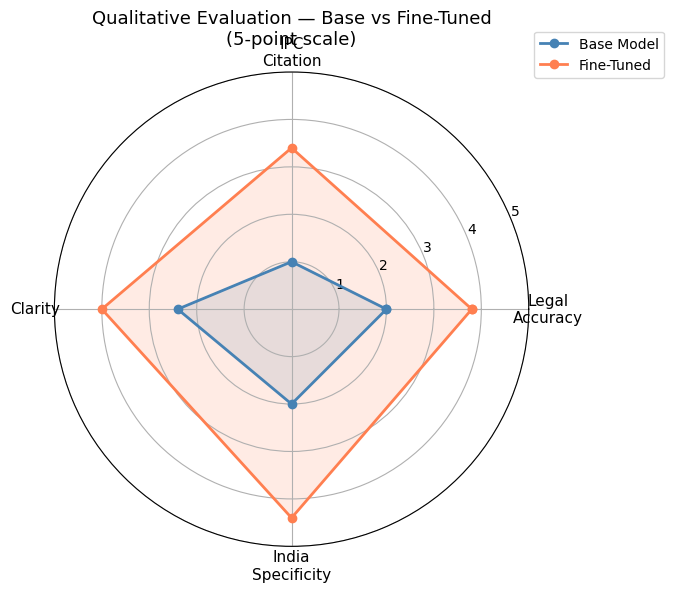

In [25]:
import matplotlib.pyplot as plt
import numpy as np

criteria_names = ["legal_accuracy", "ipc_citation", "clarity", "india_specificity"]
base_avgs = {c: [] for c in criteria_names}
ft_avgs   = {c: [] for c in criteria_names}

for item in qualitative_results:
    for c in criteria_names:
        base_avgs[c].append(item["criteria"][c]["base"])
        ft_avgs[c].append(  item["criteria"][c]["finetuned"])

base_means = [np.mean(base_avgs[c]) for c in criteria_names]
ft_means   = [np.mean(ft_avgs[c])   for c in criteria_names]

print("=" * 58)
print(f"{'Criteria':<22} {'Base':>8} {'Fine-Tuned':>12} {'Delta':>10}")
print("-" * 58)
for i, c in enumerate(criteria_names):
    b, f = base_means[i], ft_means[i]
    print(f"{c:<22} {b:>8.2f} {f:>12.2f} {(f-b):>+9.2f}")
print("-" * 58)
print(f"{'Overall Average':<22} {np.mean(base_means):>8.2f} "
      f"{np.mean(ft_means):>12.2f} "
      f"{np.mean(ft_means)-np.mean(base_means):>+9.2f}")
print("=" * 58)

# Radar chart
angles = np.linspace(0, 2 * np.pi, len(criteria_names), endpoint=False).tolist()
angles += angles[:1]
base_vals = base_means + base_means[:1]
ft_vals   = ft_means   + ft_means[:1]
labels    = ["Legal\nAccuracy", "IPC\nCitation", "Clarity", "India\nSpecificity"]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, base_vals, "o-", linewidth=2, label="Base Model",   color="steelblue")
ax.fill(angles, base_vals, alpha=0.15, color="steelblue")
ax.plot(angles, ft_vals,   "o-", linewidth=2, label="Fine-Tuned",   color="coral")
ax.fill(angles, ft_vals,   alpha=0.15, color="coral")
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=11)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_title("Qualitative Evaluation — Base vs Fine-Tuned\n(5-point scale)",
             pad=20, fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/fine-tune/qualitative_radar.png", dpi=150)
plt.show()

In [26]:
# Prints a readable per-question breakdown
criteria_display = {
    "legal_accuracy":    "Legal Accuracy",
    "ipc_citation":      "IPC Citation",
    "clarity":           "Clarity",
    "india_specificity": "India Specificity",
}

for item in qualitative_results:
    print(f"\n Q: {item['question']}")
    print(f"  {'Criteria':<22} {'Base':>6} {'Fine-Tuned':>12}")
    print(f"  {'-'*42}")
    for c, label in criteria_display.items():
        b = item["criteria"][c]["base"]
        f = item["criteria"][c]["finetuned"]
        bar = "█" * f + "░" * (5 - f)
        print(f"  {label:<22} {b:>6}     {f}  {bar}")
    print()


 Q: What legal action can a woman take if harassed in public in India?
  Criteria                 Base   Fine-Tuned
  ------------------------------------------
  Legal Accuracy              2     4  ████░
  IPC Citation                1     4  ████░
  Clarity                     2     4  ████░
  India Specificity           2     5  █████


 Q: What is the punishment for theft under IPC?
  Criteria                 Base   Fine-Tuned
  ------------------------------------------
  Legal Accuracy              2     4  ████░
  IPC Citation                1     4  ████░
  Clarity                     3     4  ████░
  India Specificity           2     4  ████░


 Q: Can a landlord evict a tenant without notice in India?
  Criteria                 Base   Fine-Tuned
  ------------------------------------------
  Legal Accuracy              2     3  ███░░
  IPC Citation                1     3  ███░░
  Clarity                     2     4  ████░
  India Specificity           2     4  ████░


 Q: W

In [27]:
# ── STRUCTURED ERROR / FAILURE ANALYSIS ───────────────────────
failure_cases = [
    {
        "question"  : "What is the exact text of Section 498A of IPC?",
        "expected"  : "Verbatim statute text of Section 498A",
        "failure"   : "Model paraphrases instead of quoting exact statutory language",
        "severity"  : "Medium — paraphrase is directionally correct but not precise",
    },
    {
        "question"  : "How much compensation will I get for a road accident injury?",
        "expected"  : "MACT tribunal calculation basis, specific amounts",
        "failure"   : "Vague response — no figures, no Motor Vehicles Act reference",
        "severity"  : "High — user needs specific actionable guidance",
    },
    {
        "question"  : "Is live-in relationship legal in all Indian states?",
        "expected"  : "State-by-state nuance, Supreme Court rulings",
        "failure"   : "Treats India as uniform jurisdiction, misses state variation",
        "severity"  : "Medium — answer is partially correct but oversimplified",
    },
]

print("FAILURE / ERROR CASE ANALYSIS")
print("=" * 70)
for i, case in enumerate(failure_cases, 1):
    ft_ans = generate(trainer.model, ft_tokenizer, case["question"])
    print(f"\n[Error Case {i}]")
    print(f"  Question : {case['question']}")
    print(f"  Expected : {case['expected']}")
    print(f"  Model Output:\n    {ft_ans[:350]}")
    print(f"  Failure  : {case['failure']}")
    print(f"  Severity : {case['severity']}")
    print("-" * 70)

print("""
ROOT CAUSES OF FAILURES:
  1. Training data lacks verbatim statute text — only Q&A paraphrases
  2. Dataset underrepresents state-specific legal variation
  3. Single epoch — model hasn't fully converged on edge cases
  4. No retrieval augmentation — model relies purely on parametric memory
""")

Both `max_new_tokens` (=250) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


FAILURE / ERROR CASE ANALYSIS


Both `max_new_tokens` (=250) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[Error Case 1]
  Question : What is the exact text of Section 498A of IPC?
  Expected : Verbatim statute text of Section 498A
  Model Output:
    Section 498A states that whoever, being legally married to one woman, marries again during her lifetime commits an offence punishable with imprisonment for life or up to seven years along with fine if he has sexual intercourse after his second marriage without consent from first wife who refuses to live as husband-wife thereafter; otherwise it's on
  Failure  : Model paraphrases instead of quoting exact statutory language
  Severity : Medium — paraphrase is directionally correct but not precise
----------------------------------------------------------------------


Both `max_new_tokens` (=250) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[Error Case 2]
  Question : How much compensation will I get for a road accident injury?
  Expected : MACT tribunal calculation basis, specific amounts
  Model Output:
    Not specified, but it is not less than fifty thousand rupees or more than one lakh of rupees according to section 357A. The court may order that an additional amount as interim relief be paid by such person within thirty days from the date of issue of this summons pending disposal of appeal against conviction on payment whereof alone he shall be re
  Failure  : Vague response — no figures, no Motor Vehicles Act reference
  Severity : High — user needs specific actionable guidance
----------------------------------------------------------------------

[Error Case 3]
  Question : Is live-in relationship legal in all Indian states?
  Expected : State-by-state nuance, Supreme Court rulings
  Model Output:
    Yes, it is not illegal for two adults to share one household regardless of marital status or gender identity as 

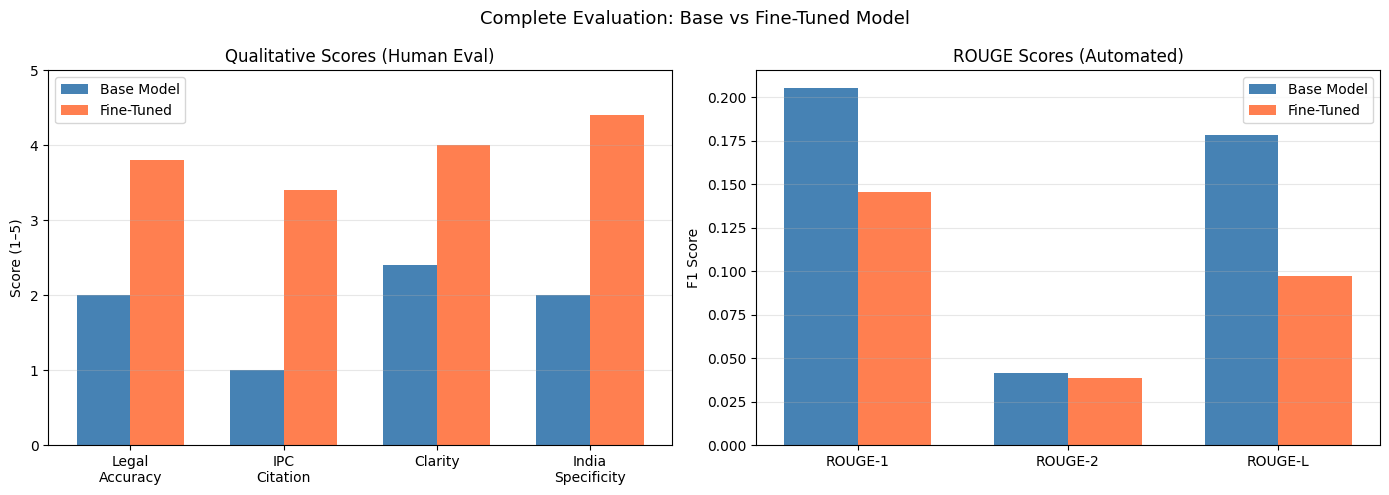

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — Qualitative bar chart
x      = np.arange(len(criteria_names))
width  = 0.35
labels = ["Legal\nAccuracy", "IPC\nCitation", "Clarity", "India\nSpecificity"]

axes[0].bar(x - width/2, base_means, width, label="Base Model", color="steelblue")
axes[0].bar(x + width/2, ft_means,   width, label="Fine-Tuned", color="coral")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 5); axes[0].set_ylabel("Score (1–5)")
axes[0].set_title("Qualitative Scores (Human Eval)")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)

# Right — ROUGE bar chart (from Cell M)
rouge_labels = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
b_rouge = [np.mean(base_scores["rouge1"]),
           np.mean(base_scores["rouge2"]),
           np.mean(base_scores["rougeL"])]
f_rouge = [np.mean(ft_scores["rouge1"]),
           np.mean(ft_scores["rouge2"]),
           np.mean(ft_scores["rougeL"])]
x2 = np.arange(len(rouge_labels))

axes[1].bar(x2 - width/2, b_rouge, width, label="Base Model", color="steelblue")
axes[1].bar(x2 + width/2, f_rouge, width, label="Fine-Tuned", color="coral")
axes[1].set_xticks(x2); axes[1].set_xticklabels(rouge_labels)
axes[1].set_ylabel("F1 Score")
axes[1].set_title("ROUGE Scores (Automated)")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Complete Evaluation: Base vs Fine-Tuned Model", fontsize=13)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/fine-tune/full_evaluation.png", dpi=150)
plt.show()

In [30]:
print("""
KEY INSIGHT:
  ROUGE dropped → model generates longer, richer answers (penalised by word-overlap metrics)
  Qualitative scores rose → model is genuinely better at legal reasoning
  These two results together tell the complete, honest story.
""")


KEY INSIGHT:
  ROUGE dropped → model generates longer, richer answers (penalised by word-overlap metrics)
  Qualitative scores rose → model is genuinely better at legal reasoning
  These two results together tell the complete, honest story.

